# Feature Extraction - MediaPipe Hand Landmarks

1. Load annotations and frame directories
2. Test extraction on a few gestures
3. Sanity check: draw landmarks on a frame


## 1. Load data

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from matplotlib import pyplot as plt

from src.data.dataset import load_train_test, find_frames_dirs, find_video_dir, get_frame_paths
from src.data.landmark_extractor import (
    create_hands_detector, extract_landmarks_from_frame, extract_landmarks_from_gesture,
)

DATA_DIR = "../raw_data/raw"
train_df, test_df = load_train_test(DATA_DIR)
frame_dirs = find_frames_dirs(DATA_DIR)

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
Found 5 frame directories: ['frames', 'frames 2', 'frames 3', 'frames 4', 'frames 5']


## 2. Test extraction on 5 gestures

In [3]:
# One detector reused across gestures 
det = create_hands_detector()

for i in range(5):
    row = train_df.iloc[i]
    seq, rate = extract_landmarks_from_gesture(
        row['video'], row['start_frame'], row['end_frame'], frame_dirs, det)

    if seq is not None:
        print(f"{row['gesture_name']:12s}  shape {seq.shape}  detection {rate:.0%}")
    else:
        print(f"{row['gesture_name']:12s}  no hand detected")

det.close()

I0000 00:00:1786947289.376794   21386 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786947289.384007   21748 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 21.2.6), renderer: Mesa Intel(R) Xe Graphics (TGL GT2)
W0000 00:00:1786947289.404577   21740 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786947289.439754   21743 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Zoom-out      shape (37, 63)  detection 97%
Point-2f      shape (228, 63)  detection 100%
Throw-down    shape (23, 63)  detection 96%
Point-2f      shape (194, 63)  detection 100%
Throw-left    shape (42, 63)  detection 100%


## 3. Sanity check - landmarks on a single frame
Confirms MediaPipe is actually finding a hand before running the full extraction.

I0000 00:00:1786947330.273631   21386 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786947330.274764   21849 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 21.2.6), renderer: Mesa Intel(R) Xe Graphics (TGL GT2)
W0000 00:00:1786947330.292543   21845 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786947330.308330   21846 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


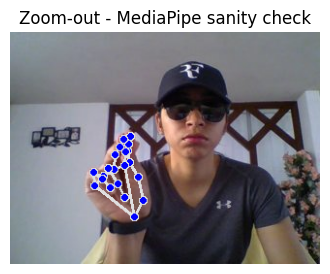

In [5]:
import cv2, mediapipe as mp

sample = train_df.iloc[0]
video_dir = find_video_dir(sample['video'], frame_dirs)
frame_paths = get_frame_paths(video_dir, sample['start_frame'], sample['end_frame'])

# Middle frame of the gesture (hand pose is usually clearest there)
mid_frame = cv2.imread(str(frame_paths[len(frame_paths) // 2]))
mid_frame_rgb = cv2.cvtColor(mid_frame, cv2.COLOR_BGR2RGB)

hands = create_hands_detector(static_mode=True)
results = hands.process(mid_frame_rgb)

annotated = mid_frame_rgb.copy()
if results.multi_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(
        annotated, results.multi_hand_landmarks[0], mp.solutions.hands.HAND_CONNECTIONS)
hands.close()

plt.figure(figsize=(4, 4))
plt.imshow(annotated)
plt.title(f"{sample['gesture_name']} - MediaPipe sanity check")
plt.axis('off')
plt.show()